# Importing libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("sample_data/housing.csv")

In [18]:
# Fill missing values
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


/tmp/ipykernel_1078/2776871284.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


In [19]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [20]:
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

/tmp/ipykernel_1078/2164095440.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
if "ocean_proximity" in df.columns:
    df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)


In [23]:
df.to_csv("cleaned_housing.csv", index=False)
print("✔ Cleaned dataset saved as cleaned_housing.csv")

✔ Cleaned dataset saved as cleaned_housing.csv


In [24]:
target = "median_house_value"

X = df.drop(target, axis=1)
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 12)
Target shape: (20640,)


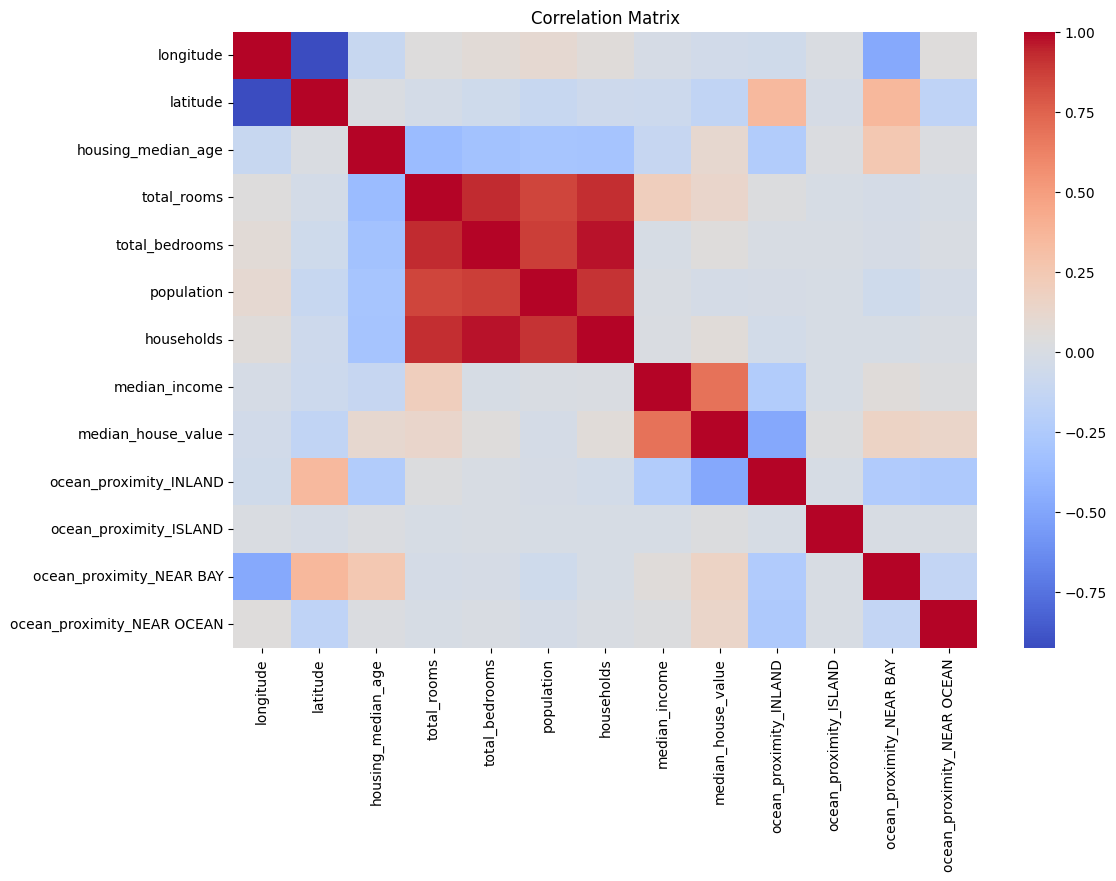

In [25]:
# Correlation Analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [26]:
# Feature selection
selected_features = [
    "median_income",
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "population",
    "total_bedrooms"
]

X_selected = df[selected_features]

print(X_selected.head())


   median_income  longitude  latitude  housing_median_age  total_rooms  \
0         8.3252    -122.23     37.88                41.0        880.0   
1         8.3014    -122.22     37.86                21.0       7099.0   
2         7.2574    -122.24     37.85                52.0       1467.0   
3         5.6431    -122.25     37.85                52.0       1274.0   
4         3.8462    -122.25     37.85                52.0       1627.0   

   population  total_bedrooms  
0       322.0           129.0  
1      2401.0          1106.0  
2       496.0           190.0  
3       558.0           235.0  
4       565.0           280.0  


In [27]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (16512, 7)
Testing set: (4128, 7)


In [28]:
# Hypothesis
print("""
HYPOTHESES:
H1: Higher median income increases house prices.
H2: Location (latitude & longitude) affects housing price.
H3: Larger number of rooms increases price.
H4: Older houses may have lower value.
""")



HYPOTHESES:
H1: Higher median income increases house prices.
H2: Location (latitude & longitude) affects housing price.
H3: Larger number of rooms increases price.
H4: Older houses may have lower value.



In [29]:
print("""
MODEL CHOSEN: Linear Regression

REASON:
- Target is continuous (house price)
- Data shows linear relationships
- Model is simple and interpretable
- Suitable baseline for prediction task
""")



MODEL CHOSEN: Linear Regression

REASON:
- Target is continuous (house price)
- Data shows linear relationships
- Model is simple and interpretable
- Suitable baseline for prediction task



In [30]:
print("✔ Week 4 Completed Successfully!")
print("✔ Ready for Week 5 (Linear Regression)")

✔ Week 4 Completed Successfully!
✔ Ready for Week 5 (Linear Regression)
